In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("sales_data.csv")
print("Dataset loaded successfully")
print("Rows, Columns :", df.shape)
df.head()

Dataset loaded successfully
Rows, Columns : (30, 3)


,Product,Region,Sales
0,Laptop,North,50000
1,Mobile,South,35000
2,Printer,East,25000
3,Laptop,West,45000
4,Mobile,North,40000


In [2]:
# ---------------- CRISP-DM : Phase 1 - Business Understanding ----------------
print("BUSINESS OBJECTIVE")
print("Identify which product and which region generate the highest sales,")
print("so that stock and marketing effort can be planned accordingly.")
print()

# ---------------- CRISP-DM : Phase 2 - Data Understanding --------------------
print("DATA UNDERSTANDING")
df.info()
print()
print("Statistical summary of the numeric column:")
print(df.describe())

BUSINESS OBJECTIVE
Identify which product and which region generate the highest sales,
so that stock and marketing effort can be planned accordingly.

DATA UNDERSTANDING
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Product  30 non-null     str  
 1   Region   30 non-null     str  
 2   Sales    30 non-null     int64
dtypes: int64(1), str(2)
memory usage: 852.0 bytes

Statistical summary of the numeric column:
              Sales
count     30.000000
mean   40033.333333
std     9575.411518
min    25000.000000
25%    32250.000000
50%    39500.000000
75%    47750.000000
max    58000.000000


In [3]:
# ---------------- CRISP-DM : Phase 3 - Data Preparation ----------------------
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows :", df.duplicated().sum())

# encode the categorical columns so that they can be used by a model
prep = df.copy()
prep["Product_Code"] = prep["Product"].astype("category").cat.codes
prep["Region_Code"] = prep["Region"].astype("category").cat.codes

print("\nPrepared data:")
prep.head()

Missing values per column:
Product    0
Region     0
Sales      0
dtype: int64

Duplicate rows : 0

Prepared data:


,Product,Region,Sales,Product_Code,Region_Code
0,Laptop,North,50000,0,1
1,Mobile,South,35000,1,2
2,Printer,East,25000,2,0
3,Laptop,West,45000,0,3
4,Mobile,North,40000,1,1


In [4]:
# ---------------- CRISP-DM : Phase 4 - Modeling ------------------------------
# A simple model: the average sales of a product-region combination is used
# to predict the sales of that combination.
model = prep.groupby(["Product", "Region"])["Sales"].mean().rename("Predicted")
prep = prep.merge(model, on=["Product", "Region"], how="left")

# ---------------- CRISP-DM : Phase 5 - Evaluation ----------------------------
prep["Error"] = prep["Sales"] - prep["Predicted"]
mae = prep["Error"].abs().mean()
rmse = np.sqrt((prep["Error"] ** 2).mean())

print("Mean Absolute Error :", round(mae, 2))
print("Root Mean Sq. Error :", round(rmse, 2))
print("Mean sales value    :", round(prep["Sales"].mean(), 2))
print("Error as % of mean  :", round(mae / prep["Sales"].mean() * 100, 2), "%")
prep[["Product", "Region", "Sales", "Predicted", "Error"]].head()

Mean Absolute Error : 1366.67
Root Mean Sq. Error : 1730.45
Mean sales value    : 40033.33
Error as % of mean  : 3.41 %


,Product,Region,Sales,Predicted,Error
0,Laptop,North,50000,52666.666667,-2666.666667
1,Mobile,South,35000,36000.000000,-1000.000000
2,Printer,East,25000,29000.000000,-4000.000000
3,Laptop,West,45000,47000.000000,-2000.000000
4,Mobile,North,40000,41333.333333,-1333.333333


In [5]:
# ---------------- CRISP-DM : Phase 6 - Deployment ----------------------------
# The model is saved as a lookup table that the business can use directly.
model.round(2).to_csv("crispdm_model.csv")
print("Model deployed as 'crispdm_model.csv'")
print()
print("Deployed lookup table:")
print(model.round(2).head(12))

Model deployed as 'crispdm_model.csv'

Deployed lookup table:
Product  Region
Laptop   East      56500.00
         North     52666.67
         South     49500.00
         West      47000.00
Mobile   East      43000.00
         North     41333.33
         South     36000.00
         West      38500.00
Printer  East      29000.00
         North     29500.00
         South     32000.00
         West      26500.00
Name: Predicted, dtype: float64


In [6]:
# ============================ SEMMA ==========================================
# ---- S : Sample -------------------------------------------------------------
sample = df.sample(n=10, random_state=42)
print("Sample of 10 records drawn from the dataset:")
print(sample)

# ---- E : Explore ------------------------------------------------------------
print("\nSales by Product:")
print(df.groupby("Product")["Sales"].agg(["count", "mean", "sum"]).round(2))

Sample of 10 records drawn from the dataset:
    Product Region  Sales
27   Laptop   West  49000
15   Laptop   West  47000
23  Printer   West  26000
17  Printer  South  32000
8   Printer  North  28000
9    Laptop  South  48000
28   Mobile  North  41000
24   Laptop  North  56000
12   Laptop  North  52000
0    Laptop  North  50000

Sales by Product:
         count     mean     sum
Product                        
Laptop      10  51100.0  511000
Mobile      10  39500.0  395000
Printer     10  29500.0  295000


In [7]:
# ---- M : Modify -------------------------------------------------------------
semma = df.copy()
semma["Sales_in_Thousands"] = semma["Sales"] / 1000
semma["Performance"] = np.where(semma["Sales"] >= semma["Sales"].mean(),
                                "High", "Low")

# ---- M : Model --------------------------------------------------------------
model2 = semma.groupby("Product")["Sales"].mean().sort_values(ascending=False)

# ---- A : Assess -------------------------------------------------------------
print("Modified dataset:")
print(semma.head())
print("\nModel - average sales per product:")
print(model2.round(2))
print("\nAssessment - top selling product :", model2.index[0])
print("Assessment - high performers      :",
      (semma["Performance"] == "High").sum(), "of", len(semma), "records")

Modified dataset:
   Product Region  Sales  Sales_in_Thousands Performance
0   Laptop  North  50000                50.0        High
1   Mobile  South  35000                35.0         Low
2  Printer   East  25000                25.0         Low
3   Laptop   West  45000                45.0        High
4   Mobile  North  40000                40.0         Low

Model - average sales per product:
Product
Laptop     51100.0
Mobile     39500.0
Printer    29500.0
Name: Sales, dtype: float64

Assessment - top selling product : Laptop
Assessment - high performers      : 14 of 30 records


In [8]:
# ============================== KDD ==========================================
# ---- Step 1 : Selection -----------------------------------------------------
selected = df[["Product", "Region", "Sales"]]
print("Step 1 - Selection : attributes selected ->", list(selected.columns))

# ---- Step 2 : Pre-processing ------------------------------------------------
clean = selected.dropna().drop_duplicates()
print("Step 2 - Pre-processing : rows after cleaning ->", len(clean))

# ---- Step 3 : Transformation ------------------------------------------------
transformed = clean.pivot_table(index="Region", columns="Product",
                                values="Sales", aggfunc="sum")
print("\nStep 3 - Transformation : data transformed into a matrix")
transformed

Step 1 - Selection : attributes selected -> ['Product', 'Region', 'Sales']
Step 2 - Pre-processing : rows after cleaning -> 30

Step 3 - Transformation : data transformed into a matrix


Product,Laptop,Mobile,Printer
Region,,,
East,113000,86000,87000
North,158000,124000,59000
South,99000,108000,96000
West,141000,77000,53000


Step 4 - Data Mining : patterns discovered
Highest selling product overall : Laptop
Highest selling region overall  : North
Best product-region combination : Laptop in North

Step 5 - Interpretation : contribution of each product (%)
Product
Laptop     42.55
Mobile     32.89
Printer    24.56
Name: Sales, dtype: float64


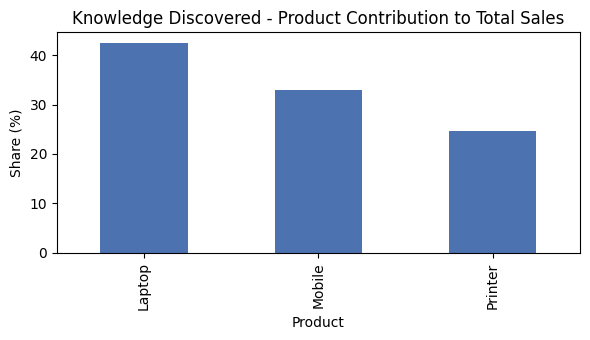

In [9]:
# ---- Step 4 : Data Mining ---------------------------------------------------
print("Step 4 - Data Mining : patterns discovered")
print("Highest selling product overall :", clean.groupby("Product")["Sales"].sum().idxmax())
print("Highest selling region overall  :", clean.groupby("Region")["Sales"].sum().idxmax())
best = transformed.stack().idxmax()
print("Best product-region combination :", best[1], "in", best[0])

# ---- Step 5 : Interpretation / Evaluation -----------------------------------
share = clean.groupby("Product")["Sales"].sum() / clean["Sales"].sum() * 100
print("\nStep 5 - Interpretation : contribution of each product (%)")
print(share.round(2))

share.plot(kind="bar", figsize=(6, 3.5), color="#4c72b0")
plt.title("Knowledge Discovered - Product Contribution to Total Sales")
plt.ylabel("Share (%)")
plt.tight_layout()
plt.show()

In [10]:
comparison = pd.DataFrame({
    "CRISP-DM": ["Business Understanding", "Data Understanding", "Data Preparation",
                 "Modeling", "Evaluation", "Deployment"],
    "SEMMA":    ["--", "Sample", "Explore / Modify", "Model", "Assess", "--"],
    "KDD":      ["Selection", "Pre-processing", "Transformation",
                 "Data Mining", "Interpretation", "--"],
})
comparison.index = ["Phase 1", "Phase 2", "Phase 3", "Phase 4", "Phase 5", "Phase 6"]
comparison

,CRISP-DM,SEMMA,KDD
Phase 1,Business Understanding,--,Selection
Phase 2,Data Understanding,Sample,Pre-processing
Phase 3,Data Preparation,Explore / Modify,Transformation
Phase 4,Modeling,Model,Data Mining
Phase 5,Evaluation,Assess,Interpretation
Phase 6,Deployment,--,--
